In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [6]:
df = pd.read_csv(r"C:\Users\USER\Documents\bank_transaction_data.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()



Shape: (2512, 16)

Columns: ['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate']

First 5 rows:


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,11/4/2024 8:08
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,11/4/2024 8:09
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,11/4/2024 8:07
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,11/4/2024 8:09
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,11/4/2024 8:06


In [13]:
print("Missing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)
print("\nBasic stats:")
df.describe()

Missing values:
TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

Data types:
TransactionID               object
AccountID                   object
TransactionAmount          float64
TransactionDate             object
TransactionType             object
Location                    object
DeviceID                    object
IP Address                  object
MerchantID                  object
Channel                     object
CustomerAge                  int64
CustomerOccupation          object
TransactionDuration          int64
LoginAttempts                int64
Acco

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [15]:
print("Shape:", df.shape)
print("\nTransaction Types:")
print(df["TransactionType"].value_counts())
print("\nChannels:")
print(df["Channel"].value_counts())

Shape: (2512, 16)

Transaction Types:
TransactionType
Debit     1944
Credit     568
Name: count, dtype: int64

Channels:
Channel
Branch    868
ATM       833
Online    811
Name: count, dtype: int64


EDA Visualization

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

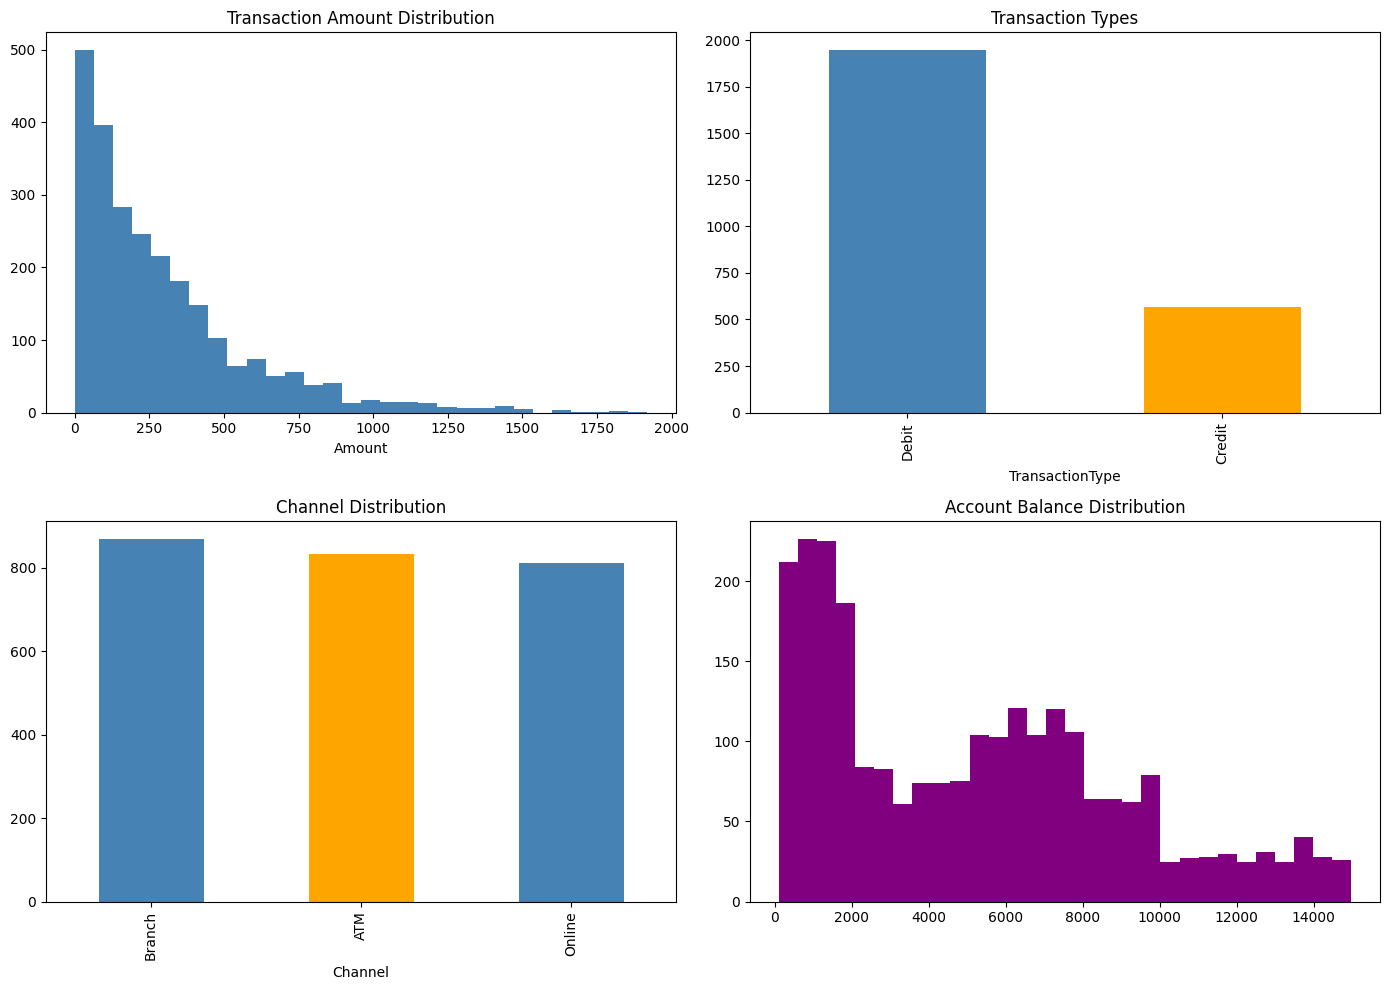

In [22]:
# Transaction Amount Distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].hist(df["TransactionAmount"], bins=30, color="steelblue")
axes[0,0].set_title("Transaction Amount Distribution")
axes[0,0].set_xlabel("Amount")

# Transaction Type
df["TransactionType"].value_counts().plot(kind="bar", ax=axes[0,1], color=["steelblue","orange"])
axes[0,1].set_title("Transaction Types")

# Channel Distribution
df["Channel"].value_counts().plot(kind="bar", ax=axes[1,0], color=["steelblue","orange"])
axes[1,0].set_title("Channel Distribution")

# Account Balance Distribution
axes[1,1].hist(df["AccountBalance"], bins=30, color="purple")
axes[1,1].set_title("Account Balance Distribution")


plt.tight_layout()
plt.show()

RFM Analysis

In [23]:
import pandas as pd


In [24]:
# Convert dates
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
snapshot_date = df["TransactionDate"].max()

In [26]:
# Build RFM
rfm = df.groupby("AccountID").agg(
    Recency=("TransactionDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("TransactionID", "count"),
    Monetary=("TransactionAmount", "sum")
).reset_index()

print(rfm.head(10))
print("\nRFM Stats:")
print(rfm.describe())

  AccountID  Recency  Frequency  Monetary
0   AC00001       48          2    260.76
1   AC00002       11          7   2056.21
2   AC00003       90          5   1266.34
3   AC00004        0          9   2180.08
4   AC00005       28          9   3131.77
5   AC00006       88          4   1017.72
6   AC00007       35          5   1495.38
7   AC00008       41          1     76.16
8   AC00009        7          5    984.08
9   AC00010       32          7   2768.67

RFM Stats:
          Recency   Frequency     Monetary
count  495.000000  495.000000   495.000000
mean    68.478788    5.074747  1510.213273
std     68.642056    2.294261   948.517120
min      0.000000    1.000000     7.080000
25%     20.000000    3.000000   787.010000
50%     47.000000    5.000000  1356.750000
75%     95.500000    7.000000  2060.195000
max    363.000000   12.000000  5570.340000


In [28]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], q=4, labels=[4,3,2,1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=4, labels=[1,2,3,4])
rfm["M_Score"] = pd.qcut(rfm["Monetary"], q=4, labels=[1,2,3,4])

rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)

# Segment Labels
def segment_customer(row):
    score = int(row["R_Score"]) + int(row["F_Score"]) + int(row["M_Score"])
    if score > 10:
        return "Champion"
    elif score > 8:
        return "Loyal Customer"
    elif score > 6:
        return "Potential Loyalist"
    elif score < 4:
        return "At Risk"
    else:
        return "Lost Customer"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

print(rfm["Segment"].value_counts())

Segment
Lost Customer         154
Loyal Customer        133
Potential Loyalist     96
Champion               72
At Risk                40
Name: count, dtype: int64


K Means Clustering

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


Scale RFM Features

In [30]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency","Monetary"]])


Find the Best Clusters

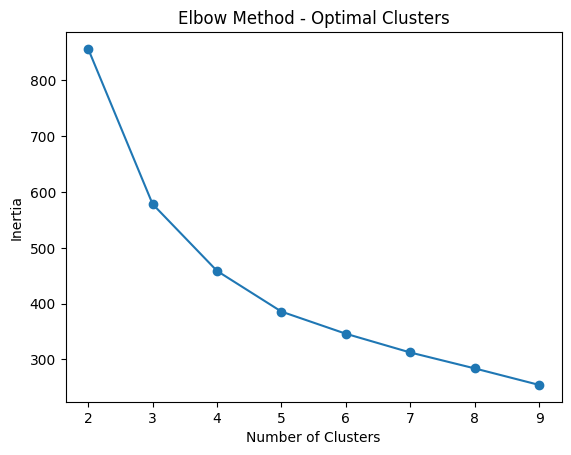

In [32]:
inertia = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2,10), inertia, marker='o')
plt.title("Elbow Method - Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

Train with 4 Clusters

In [33]:
km = KMeans(n_clusters=4, random_state=42)
rfm["Cluster"] = km.fit_predict(rfm_scaled)

In [35]:
print(rfm["Cluster"].value_counts())
print("\n Cluster Summary:")
print(rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean())

Cluster
2    180
3    154
1    102
0     59
Name: count, dtype: int64

 Cluster Summary:
            Recency  Frequency     Monetary
Cluster                                    
0        216.220339   2.491525   653.484576
1         42.009804   8.009804  2913.153725
2         43.150000   5.700000  1636.038389
3         59.012987   3.389610   762.151883


In [49]:
mon_med = float(rfm["Monetary"].median())
freq_med = float(rfm["Frequency"].median())
rec_med = float(rfm["Recency"].median())

In [55]:
import numpy as np

conditions = [
    (rfm["Monetary"] > mon_med) & (rfm["Frequency"] > freq_med),
    (rfm["Monetary"] > mon_med) & (rfm["Recency"] < rec_med),
    (rfm["Recency"] > rec_med) & (rfm["Frequency"] < freq_med)
]

labels = ["Champion", "Loyal Customer", "At Risk"]

rfm["Segment"] = np.select(conditions, labels, default="Potential Loyalist")

print(rfm["Segment"].value_counts())

Segment
Champion              169
Potential Loyalist    153
At Risk               138
Loyal Customer         35
Name: count, dtype: int64


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

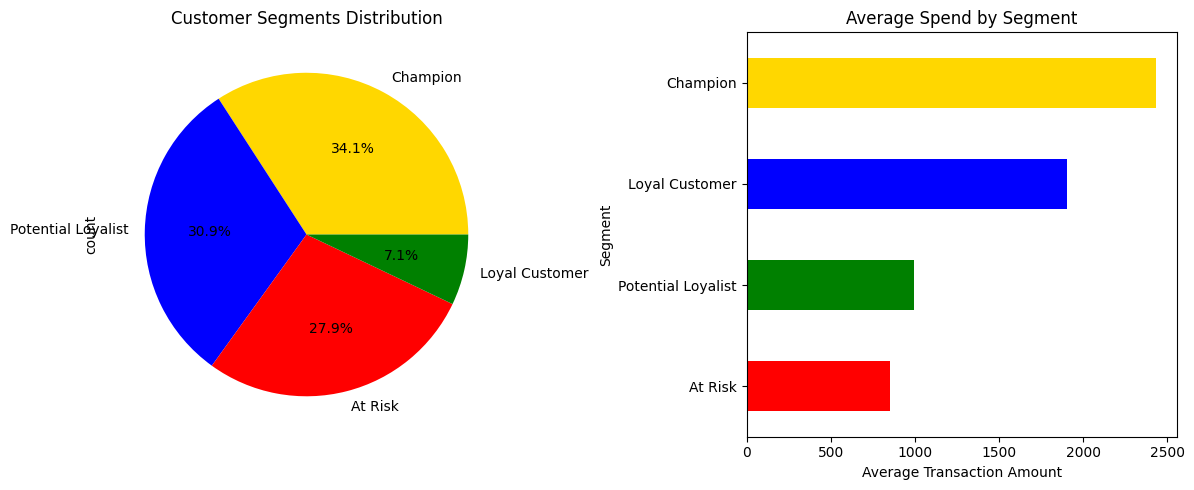

In [61]:
# Segment Distribution Pie Chart
plt.figure(figsize=(12,5))


plt.subplot(1, 2, 1)
rfm["Segment"].value_counts().plot(
    kind="pie", autopct="%1.1f%%",
    colors=["gold", "blue", "red", "green"]
)
plt.title("Customer Segments Distribution")

# Monetary by Segment
plt.subplot(1, 2, 2)
rfm.groupby("Segment")["Monetary"].mean().sort_values().plot(
    kind="barh",
    color=["red", "green", "blue", "gold"]
)
plt.title("Average Spend by Segment")
plt.xlabel("Average Transaction Amount")

plt.tight_layout()
plt.show()

In [62]:
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [63]:
x = rfm[["Recency", "Frequency", "Monetary"]]
y = rfm["Segment"]

In [64]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [65]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x, y_encoded)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
print("Model trained successfully!")
print("Classes:", le.classes_)

Model trained successfully!
Classes: ['At Risk' 'Champion' 'Loyal Customer' 'Potential Loyalist']


In [67]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(x)

In [68]:
print("SHAP values generated!")

SHAP values generated!


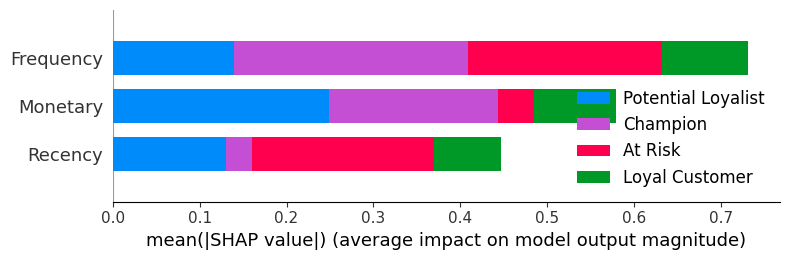

In [81]:
shap.summary_plot(
    shap_values,
    x,
    class_names=le.classes_,
    plot_type="bar"
)


In [83]:
import pickle

pickle.dump(rf_model, open("segmentation_model.pkl", "wb"))
pickle.dump(le, open("label_encode.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Models saved successfully!")

Models saved successfully!


In [84]:
print(df["TransactionType"].value_counts())
print(df["Channel"].value_counts())
print(df["CustomerOccupation"].value_counts())

TransactionType
Debit     1944
Credit     568
Name: count, dtype: int64
Channel
Branch    868
ATM       833
Online    811
Name: count, dtype: int64
CustomerOccupation
Student     657
Doctor      631
Engineer    625
Retired     599
Name: count, dtype: int64


In [89]:
def assign_intent(row):
    if row["TransactionType"] == "Debit" and row["Channel"] =="ATM":
        return "Cash Withdrawal"
    elif row["TransactionType"] =="Debit" and row["Channel"] == "Online":
        return "Online Purchase"
    elif row["TransactionType"] == "Debit" and row["Channel"] == "Branch":
        return "Bill Payment"
    elif row["TransactionType"] == "Credit" and row["Channel"] == "Branch":
        return "Deposit"
    elif row["TransactionType"] == "Credit" and row["Channel"] == "Online":
        return "Online Transfer"
    else:
        return "Branch Transfer"
    

df["Intent"] = df.apply(assign_intent, axis=1)
print(df["Intent"].value_counts())


Intent
Cash Withdrawal    760
Bill Payment       617
Online Purchase    567
Deposit            251
Online Transfer    244
Branch Transfer     73
Name: count, dtype: int64


In [90]:
from sklearn.preprocessing import LabelEncoder

In [94]:
le_type = LabelEncoder()
le_channel = LabelEncoder()
le_occupation = LabelEncoder()

df["TransactionType_enc"] = le_type.fit_transform(df["TransactionType"])
df["Channel_enc"] = le_channel.fit_transform(df["Channel"])
df["Occupation_enc"] = le_occupation.fit_transform(df["CustomerOccupation"])

x_intent = df[[
    "TransactionAmount",
    'AccountBalance',
    "TransactionType_enc",
    "Channel_enc",
    "Occupation_enc",
    "CustomerAge",
    "LoginAttempts",
    "TransactionDuration"
]]

y_intent = df["Intent"]
print("Features ready !")
print(x_intent.shape)

Features ready !
(2512, 8)


In [95]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [97]:
x_train, x_test, y_train, y_test = train_test_split(
    x_intent, y_intent,
    test_size=0.2,
    random_state=42
)

In [98]:
intent_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
intent_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [100]:
y_pred = intent_model.predict(x_test)
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

   Bill Payment       1.00      1.00      1.00       131
Branch Transfer       1.00      1.00      1.00        12
Cash Withdrawal       1.00      1.00      1.00       154
        Deposit       1.00      1.00      1.00        55
Online Purchase       1.00      1.00      1.00       106
Online Transfer       1.00      1.00      1.00        45

       accuracy                           1.00       503
      macro avg       1.00      1.00      1.00       503
   weighted avg       1.00      1.00      1.00       503



In [102]:
import pickle

pickle.dump(intent_model, open("intent_model.pkl", "wb"))
pickle.dump(le_type, open("le_type.pkl", "wb"))
pickle.dump(le_channel, open("le_channel.pkl", "wb"))
pickle.dump(le_occupation, open("le_occupation.pkl", "wb"))


print("Intent model saved!")

Intent model saved!


In [ ]:
import pickle
import os

print(os.getcwd())

path = r"C:\Users\USER\anaconda_projects\db\nlp\bank_transaction\\"      

pickle.dump(scaler, open(path + "scaler.pkl", "wb"))

pickle.dump(rf_model, open(path + "segmentation_model.pkl", "wb"))
pickle.dump(intent_model, open(path + "intent_model.pkl", "wb"))
pickle.dump(le, open(path + "label_encoder.pkl", "wb"))
pickle.dump(le_type, open(path + "le_type.pkl", "wb"))
pickle.dump(le_channel, open(path + "le_channel.pkl", "wb"))
pickle.dump(le_occupation, open(path + "le_occupation.pkl", "wb"))

print("All models saved to bank_transaction folder!")

c:\Users\USER\anaconda_projects\db\nlp\bank_transaction
All models saved to bank_transaction folder!


In [109]:
print(type(scaler))
print(scaler)

<class 'sklearn.preprocessing._data.StandardScaler'>
StandardScaler()


In [110]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

In [111]:
path = r"C:\Users\USER\anaconda_projects\db\nlp\bank_transaction"

In [112]:
pickle.dump(scaler, open(path + "scaler.pkl", "wb"))
print("Scaler saved !")

Scaler saved !


In [113]:
import os
print(os.path.exists(path + "scaler.pkl"))

True
